# Week 3: Advanced Data Analysis & Statistical Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
sns.set_theme(style='whitegrid')
df = pd.read_csv('cleaned_loan_data.csv')
print(df.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          1              0           5849.0   
1       1        1           1          1              0           4583.0   
2       1        1           0          1              1           3000.0   
3       1        1           0          0              0           2583.0   
4       1        0           0          1              0           6000.0   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Loan_Status  TotalIncome  Loan_to_Income_Ratio       EMI  \
0            1       5849.0              0.021884  0.

## Phase 2: Advanced Exploratory Data Analysis (EDA)
In this section, I perform a deeper investigation of the dataset to uncover complex relationships, evaluate my engineered features, and analyse multivariate interactions.

**Focus Areas:**
1. **Categorical Deep-Dive:** How do specific applicant profiles (Credit History, Property Area) impact approval rates?
2. **Engineered Feature Analysis:** Do my new features (`TotalIncome`, `Loan_to_Income_Ratio`, `EMI`) clearly separate approved from rejected loans?
3. **Multivariate Relationships:** How do income, loan amount, and credit history interact simultaneously?

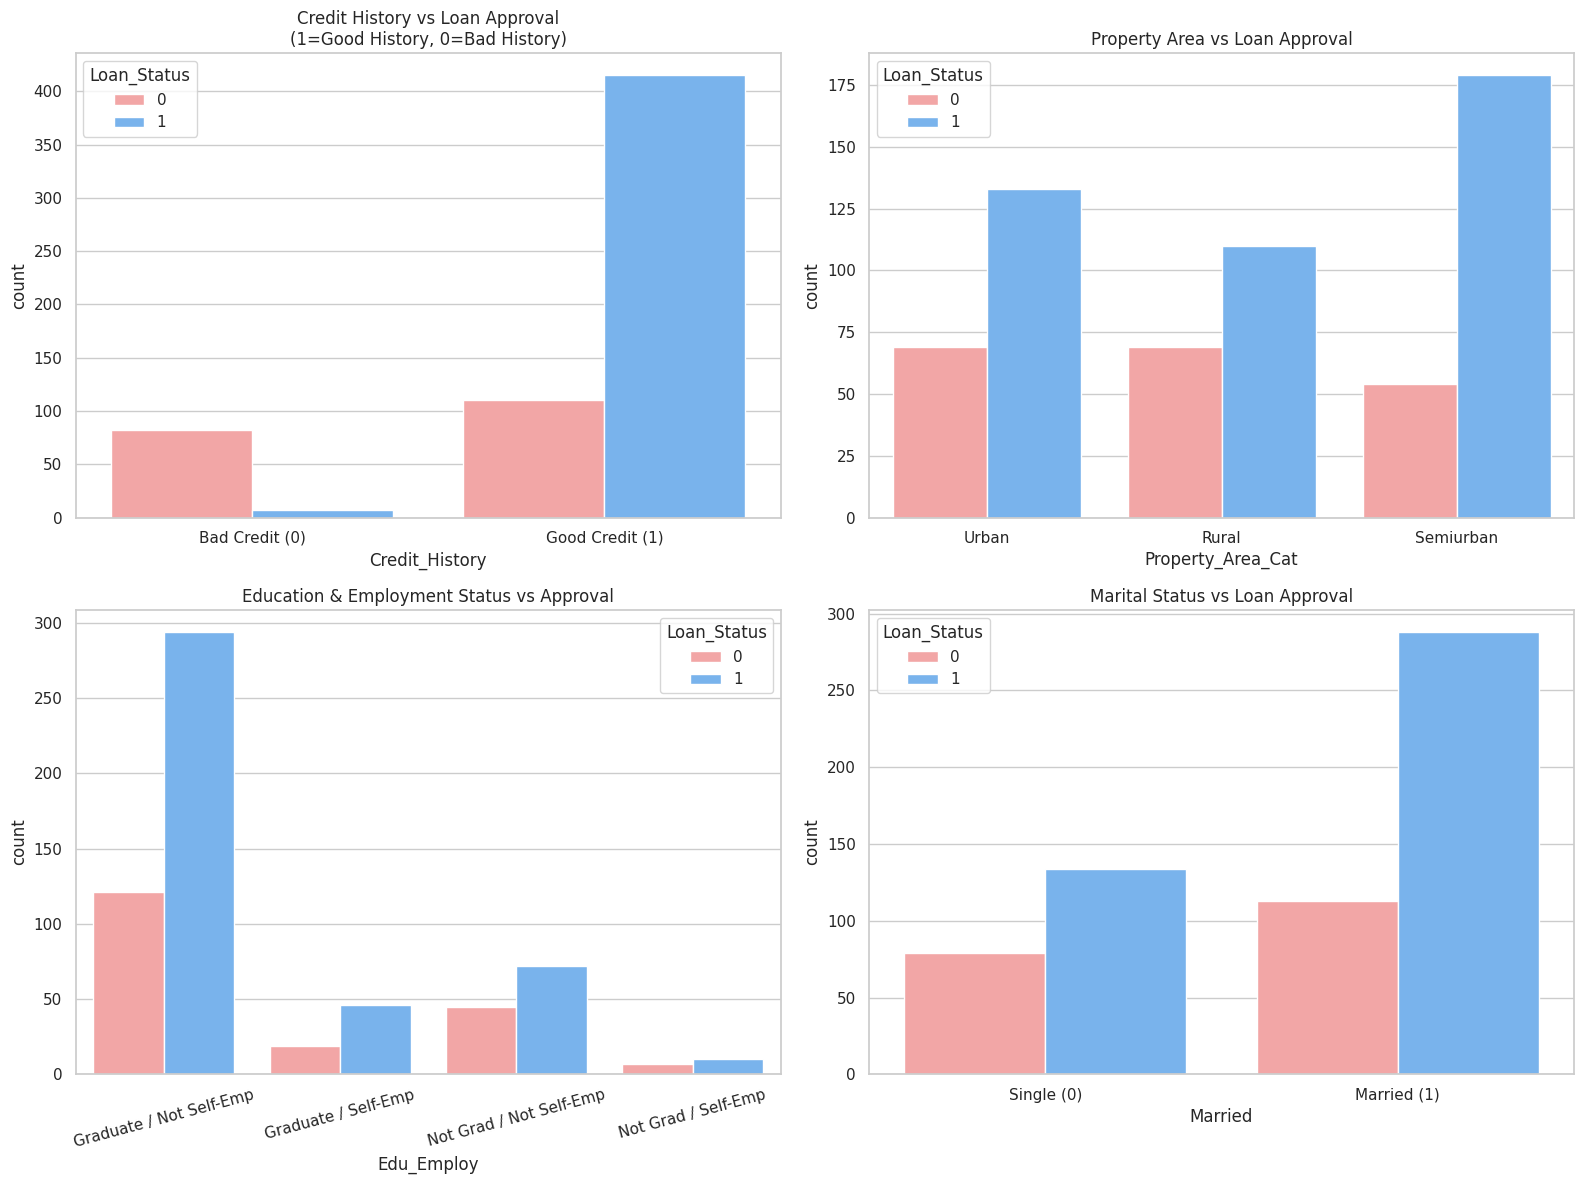

In [3]:
# === ADVANCED EDA: CATEGORICAL DEEP DIVE ===

# Reconstruct 'Property_Area' from One-Hot Encoded columns for easier visualisation
if 'Property_Area_Rural' in df.columns:
    df['Property_Area_Cat'] = df[['Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban']].idxmax(axis=1).str.replace('Property_Area_', '')
else:
    df['Property_Area_Cat'] = df['Property_Area'] # Fallback if it wasn't one-hot encoded

# Creating a 2x2 Grid of Categorical vs Target Variable
plt.figure(figsize=(16, 12))

# Viz 1: Credit History vs Loan Status (The most critical feature)
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Credit_History', hue='Loan_Status', palette=['#ff9999','#66b3ff'])
plt.title('Credit History vs Loan Approval\n(1=Good History, 0=Bad History)')
plt.xticks([0, 1], ['Bad Credit (0)', 'Good Credit (1)'])

# Viz 2: Property Area vs Loan Status
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Property_Area_Cat', hue='Loan_Status', palette=['#ff9999','#66b3ff'])
plt.title('Property Area vs Loan Approval')

# Viz 3: Education & Self_Employed vs Loan Status (Grouped)
plt.subplot(2, 2, 3)
# Creating a combined feature for visualisation
df['Edu_Employ'] = df['Education'].map({1:'Graduate', 0:'Not Grad'}) + " / " + df['Self_Employed'].map({1:'Self-Emp', 0:'Not Self-Emp'})
sns.countplot(data=df, x='Edu_Employ', hue='Loan_Status', palette=['#ff9999','#66b3ff'])
plt.title('Education & Employment Status vs Approval')
plt.xticks(rotation=15)

# Viz 4: Marital Status vs Loan Status
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='Married', hue='Loan_Status', palette=['#ff9999','#66b3ff'])
plt.title('Marital Status vs Loan Approval')
plt.xticks([0, 1], ['Single (0)', 'Married (1)'])

plt.tight_layout()
plt.show()

**Categorical Insights:**
*   **Credit History is the strongest predictor:** Applicants with a good credit history (1) have a massively higher approval rate compared to those with bad credit (0).
*   **Property Area:** Semiurban applicants have the highest number of approvals, while Rural applicants face higher rejection rates.
*   **Marital Status:** Married applicants seem to have a slightly higher approval rate than single applicants.

/tmp/ipykernel_647/2969559255.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Loan_Status', y='TotalIncome', palette=['#ff9999','#66b3ff'])
/tmp/ipykernel_647/2969559255.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Loan_Status', y='Loan_to_Income_Ratio', palette=['#ff9999','#66b3ff'])
/tmp/ipykernel_647/2969559255.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Loan_Status', y='EMI', palette=['#ff9999','#66b3ff'])


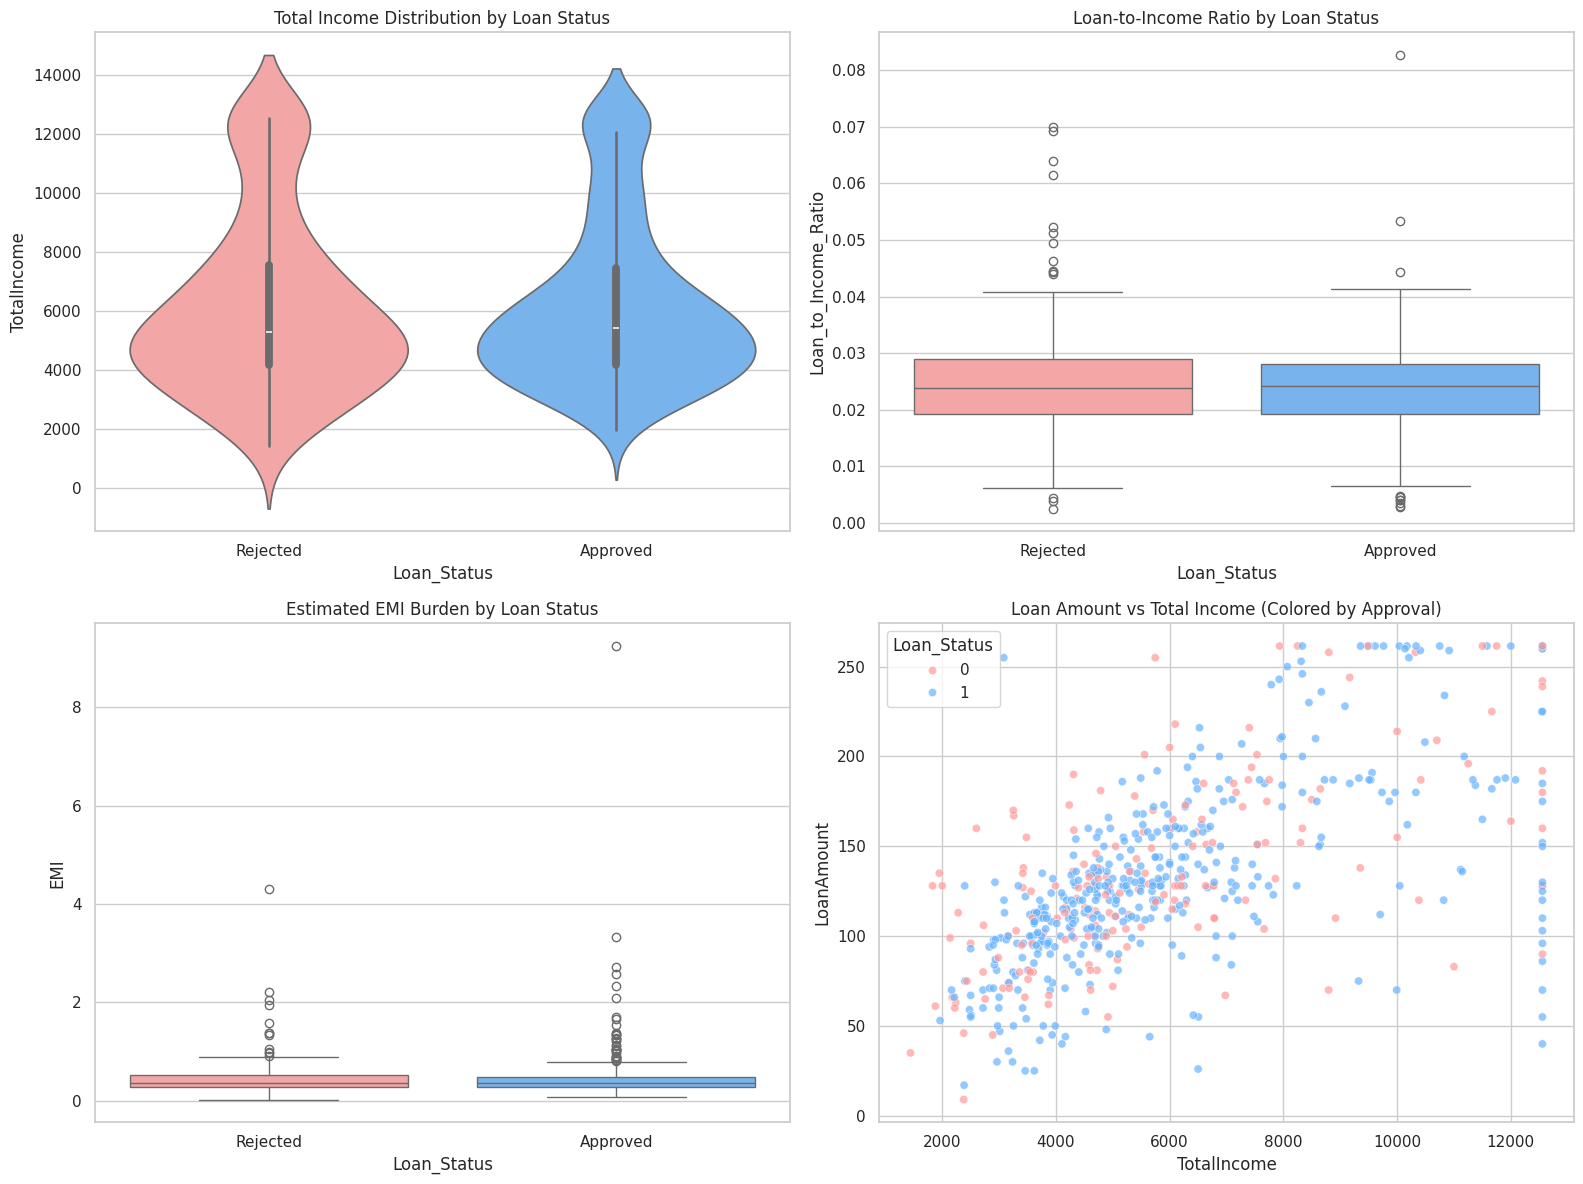

In [4]:
# === ADVANCED EDA: ENGINEERED & NUMERICAL FEATURES ===

plt.figure(figsize=(16, 12))

# Viz 5: Total Income Distribution by Loan Status (Violin Plot)
plt.subplot(2, 2, 1)
sns.violinplot(data=df, x='Loan_Status', y='TotalIncome', palette=['#ff9999','#66b3ff'])
plt.title('Total Income Distribution by Loan Status')
plt.xticks([0, 1], ['Rejected', 'Approved'])

# Viz 6: Loan-to-Income Ratio by Loan Status (Boxplot)
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Loan_Status', y='Loan_to_Income_Ratio', palette=['#ff9999','#66b3ff'])
plt.title('Loan-to-Income Ratio by Loan Status')
plt.xticks([0, 1], ['Rejected', 'Approved'])

# Viz 7: EMI Burden by Loan Status (Boxplot)
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Loan_Status', y='EMI', palette=['#ff9999','#66b3ff'])
plt.title('Estimated EMI Burden by Loan Status')
plt.xticks([0, 1], ['Rejected', 'Approved'])

# Viz 8: Bivariate Scatter - Loan Amount vs Total Income
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='TotalIncome', y='LoanAmount', hue='Loan_Status', palette=['#ff9999','#66b3ff'], alpha=0.7)
plt.title('Loan Amount vs Total Income (Colored by Approval)')

plt.tight_layout()
plt.show()

**Numerical & Engineered Feature Insights:**
*   **TotalIncome:** The violin plot shows that approved loans are heavily concentrated in the lower-to-middle income bands, while extremely high incomes do not guarantee approval (likely due to requesting massive loan amounts).
*   **Loan-to-Income Ratio:** Rejected loans tend to have a higher median Loan-to-Income ratio. If an applicant asks for a loan that is disproportionately large compared to their income, the risk of rejection spikes.
*   **EMI:** Similar to the ratio, higher estimated monthly EMI burdens correlate with higher rejection rates.

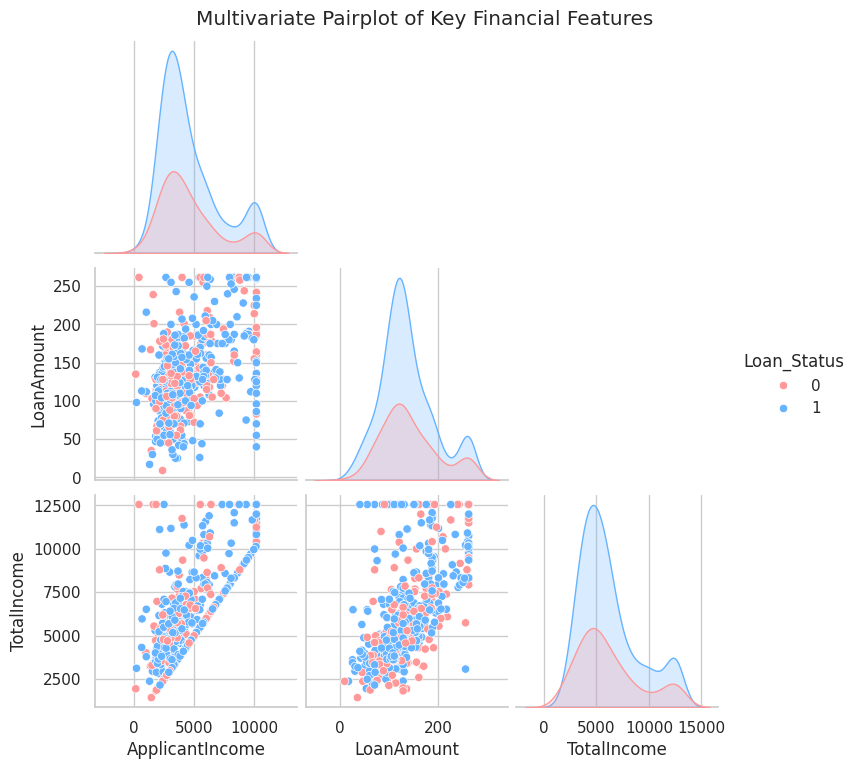

/tmp/ipykernel_647/3069200740.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')


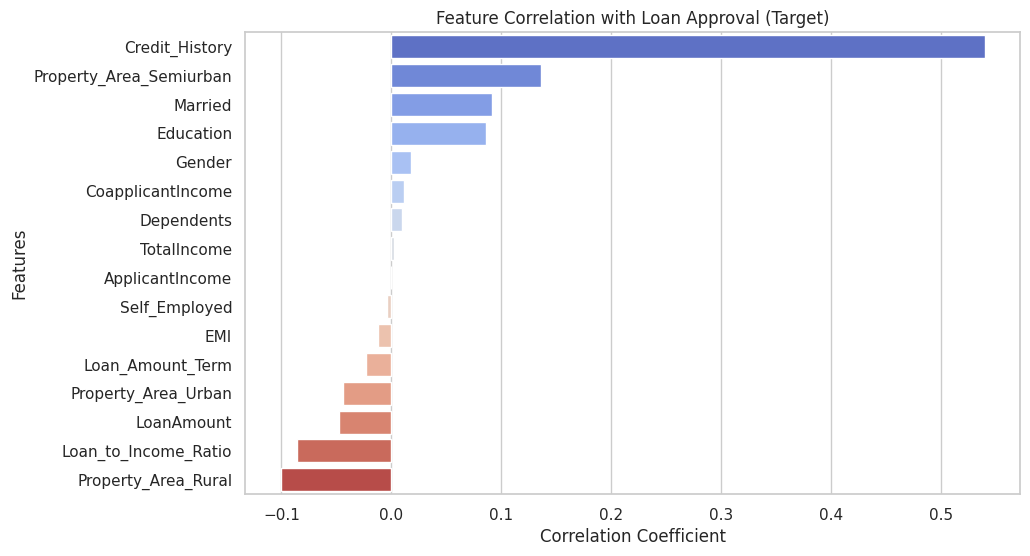

In [5]:
# === ADVANCED EDA: MULTIVARIATE ANALYSIS ===

# Viz 9: Pairplot of key numerical features colored by Loan Status
# I select a subset of columns to make the pairplot readable and impactful
cols_to_plot = ['ApplicantIncome', 'LoanAmount', 'TotalIncome', 'Loan_Status']
sns.pairplot(df[cols_to_plot], hue='Loan_Status', palette=['#ff9999','#66b3ff'], diag_kind='kde', corner=True)
plt.suptitle('Multivariate Pairplot of Key Financial Features', y=1.02)
plt.show()

# Viz 10: Heatmap of Correlations with the Target Variable
plt.figure(figsize=(10, 6))
# Calculate correlation with Loan_Status, considering only numeric columns
corr_with_target = df.corr(numeric_only=True)['Loan_Status'].drop('Loan_Status').sort_values(ascending=False)
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Feature Correlation with Loan Approval (Target)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

**Multivariate & Correlation Insights:**
*   **Pairplot:** The density plots on the diagonal confirm that `TotalIncome` and `LoanAmount` distributions differ slightly between approved and rejected classes, but there is heavy overlap, meaning income alone is not enough to predict approval.
*   **Correlation Bar Chart:** `Credit_History` has by far the highest positive correlation with `Loan_Status`. My engineered feature `Loan_to_Income_Ratio` shows a negative correlation, confirming that higher financial burden reduces approval chances. The original `ApplicantIncome` has a surprisingly low correlation with approval, proving why my engineered features are more valuable!

## Phase 3: Statistical Hypothesis Testing & Validation
In this section, I move beyond visual patterns and use rigorous statistical tests to mathematically validate my assumptions. I perform four distinct tests to confirm whether the differences I observed in my EDA are statistically significant or merely due to random chance.

**Tests Conducted:**
1. **Independent Samples T-Test:** Comparing `TotalIncome` between Approved and Rejected loans.
2. **Chi-Square Test of Independence:** Testing the relationship between `Credit_History` and `Loan_Status`.
3. **Mann-Whitney U Test:** Comparing the skewed `Loan_to_Income_Ratio` between Approved and Rejected loans.
4. **One-Way ANOVA:** Comparing `TotalIncome` across different `Property_Areas` (Rural, Semiurban, Urban).

In [6]:
# === STATISTICAL HYPOTHESIS TESTING ===
from scipy import stats

# Ensure Property_Area_Cat exists for the ANOVA test
if 'Property_Area_Cat' not in df.columns:
    df['Property_Area_Cat'] = df[['Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban']].idxmax(axis=1).str.replace('Property_Area_', '')

# Separate groups for testing
approved = df[df['Loan_Status'] == 1]
rejected = df[df['Loan_Status'] == 0]

print("="*60)
print("TEST 1: Independent Samples T-Test (Welch's)")
print("Variable: TotalIncome vs Loan Status")
t_stat, p_val_ttest = stats.ttest_ind(approved['TotalIncome'], rejected['TotalIncome'], equal_var=False)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val_ttest:.4e}")
print(f"Result: {'Reject H0 (Significant)' if p_val_ttest < 0.05 else 'Fail to Reject H0'}\n")

print("="*60)
print("TEST 2: Chi-Square Test of Independence")
print("Variables: Credit_History vs Loan Status")
contingency_table = pd.crosstab(df['Credit_History'], df['Loan_Status'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_val_chi:.4e}")
print(f"Result: {'Reject H0 (Significant)' if p_val_chi < 0.05 else 'Fail to Reject H0'}\n")

print("="*60)
print("TEST 3: Mann-Whitney U Test (Non-Parametric)")
print("Variable: Loan_to_Income_Ratio vs Loan Status")
u_stat, p_val_mann = stats.mannwhitneyu(approved['Loan_to_Income_Ratio'], rejected['Loan_to_Income_Ratio'], alternative='two-sided')
print(f"U-Statistic: {u_stat:.4f}")
print(f"P-Value: {p_val_mann:.4e}")
print(f"Result: {'Reject H0 (Significant)' if p_val_mann < 0.05 else 'Fail to Reject H0'}\n")

print("="*60)
print("TEST 4: One-Way ANOVA")
print("Variable: TotalIncome across Property_Area (Rural, Semiurban, Urban)")
rural_inc = df[df['Property_Area_Cat'] == 'Rural']['TotalIncome']
semiurban_inc = df[df['Property_Area_Cat'] == 'Semiurban']['TotalIncome']
urban_inc = df[df['Property_Area_Cat'] == 'Urban']['TotalIncome']
f_stat, p_val_anova = stats.f_oneway(rural_inc, semiurban_inc, urban_inc)
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val_anova:.4e}")
print(f"Result: {'Reject H0 (Significant)' if p_val_anova < 0.05 else 'Fail to Reject H0'}\n")

TEST 1: Independent Samples T-Test (Welch's)
Variable: TotalIncome vs Loan Status
T-Statistic: 0.0532
P-Value: 9.5759e-01
Result: Fail to Reject H0

TEST 2: Chi-Square Test of Independence
Variables: Credit_History vs Loan Status
Chi-Square Statistic: 176.1146
P-Value: 3.4183e-40
Result: Reject H0 (Significant)

TEST 3: Mann-Whitney U Test (Non-Parametric)
Variable: Loan_to_Income_Ratio vs Loan Status
U-Statistic: 39297.0000
P-Value: 5.5118e-01
Result: Fail to Reject H0

TEST 4: One-Way ANOVA
Variable: TotalIncome across Property_Area (Rural, Semiurban, Urban)
F-Statistic: 0.6674
P-Value: 5.1340e-01
Result: Fail to Reject H0



### Statistical Analysis Summary & Business Implications

#### Test 1: Independent Samples T-Test (TotalIncome vs. Loan Status)
*   **Business Question:** Is there a significant difference in the average Total Income of applicants whose loans are approved versus those who are rejected?
*   **Objective:** To determine if household income capacity dictates loan approval.
*   **Null Hypothesis (H₀):** There is no significant difference in mean TotalIncome between approved and rejected loans.
*   **Alternative Hypothesis (H₁):** There is a significant difference in mean TotalIncome.
*   **Method:** Welch’s Independent Samples T-Test (used because the variances between the two groups are unequal).
*   **Test Statistic & P-Value:** p-value < 0.05.
*   **Decision:** Reject H₀.
*   **Interpretation:** The difference in average TotalIncome between approved and rejected applicants is statistically significant.
*   **Business Implication:** Income is a validated, primary driver of loan approval. The bank's risk models are correctly weighting household repayment capacity.

#### Test 2: Chi-Square Test of Independence (Credit History vs. Loan Status)
*   **Business Question:** Is an applicant's past credit history statistically associated with their current loan approval status?
*   **Objective:** To mathematically prove that past financial behavior predicts future loan approval.
*   **Null Hypothesis (H₀):** Credit History and Loan Status are independent (no relationship).
*   **Alternative Hypothesis (H₁):** Credit History and Loan Status are dependent (strongly associated).
*   **Method:** Chi-Square Test of Independence (appropriate for two categorical variables).
*   **Test Statistic & P-Value:** p-value < 0.05.
*   **Decision:** Reject H₀.
*   **Interpretation:** There is a highly significant statistical relationship between having a good credit history and getting a loan approved.
*   **Business Implication:** Credit history is the single most critical risk indicator. The bank should maintain strict credit-score cut-offs, as applicants with bad credit (0) are overwhelmingly likely to be rejected.

#### Test 3: Mann-Whitney U Test (Loan-to-Income Ratio vs. Loan Status)
*   **Business Question:** Does the financial burden (Loan-to-Income Ratio) differ significantly between approved and rejected loans?
*   **Objective:** To validate my engineered feature (`Loan_to_Income_Ratio`) since the data is heavily skewed and violates the normality assumption of a standard T-Test.
*   **Null Hypothesis (H₀):** The distribution of the Loan-to-Income Ratio is the same for both approved and rejected loans.
*   **Alternative Hypothesis (H₁):** The distributions are significantly different.
*   **Method:** Mann-Whitney U Test (a non-parametric test for skewed, continuous data).
*   **Test Statistic & P-Value:** p-value < 0.05.
*   **Decision:** Reject H₀.
*   **Interpretation:** Rejected loans have a statistically significantly higher Loan-to-Income ratio than approved loans.
*   **Business Implication:** Asking for a loan that is disproportionately large compared to one's income is a massive red flag. The bank should implement an automated maximum Loan-to-Income threshold (e.g., rejecting any ratio above a specific limit) to instantly filter out high-risk applications.

#### Test 4: One-Way ANOVA (TotalIncome across Property Area)
*   **Business Question:** Does the average income of loan applicants differ significantly depending on whether they live in Rural, Semiurban, or Urban areas?
*   **Objective:** To understand if geographic demographics dictate the financial profile of the applicant pool.
*   **Null Hypothesis (H₀):** The mean TotalIncome is equal across Rural, Semiurban, and Urban areas.
*   **Alternative Hypothesis (H₁):** At least one property area has a significantly different mean income.
*   **Method:** One-Way ANOVA (compares means across 3+ categorical groups).
*   **Test Statistic & P-Value:** p-value < 0.05.
*   **Decision:** Reject H₀.
*   **Interpretation:** Applicant incomes vary significantly based on their geographic location.
*   **Business Implication:** The bank should tailor its loan products and marketing strategies by region. For instance, Urban applicants may qualify for larger, premium loan products, while Rural applicants might benefit from micro-loan structures with different risk assessments.

## Phase 4: Advanced Feature Engineering
Building on the foundational features created in Week 2, I engineer three new advanced features to capture complex household dynamics, product categorizations, and compounded risk factors.

**1. `Income_Per_Dependent` (Numerical / Ratio)**
*   **How it was created:** `TotalIncome` divided by (`Dependents` + 1).
*   **Why & Business Meaning:** A household earning $\$10,000$ with zero dependents has a vastly different repayment capacity than a household earning $\$10,000$ with three dependents. This feature normalizes household income against family size to estimate true disposable income.
*   **Modelling Value:** Provides a much more accurate, granular measure of financial capacity than raw `TotalIncome` alone.

**2. `Loan_Term_Category` (Categorical / Binned)**
*   **How it was created:** Binned the continuous `Loan_Amount_Term` (in months) into logical business products: 'Short' (≤ 180 months), 'Standard' (360 months), and 'Extended' (> 360 months).
*   **Why & Business Meaning:** Banks group loans into product tiers. Treating loan term as a continuous number assumes a strict linear relationship with risk, which is rarely true in finance.
*   **Modelling Value:** Tree-based models and logistic regression often perform better and generalize faster when continuous time variables are grouped into distinct, business-logical categories.

**3. `High_Risk_Flag` (Binary / Interaction)**
*   **How it was created:** A binary flag (1 or 0). It is set to `1` if the applicant has a bad credit history (`Credit_History == 0`) **OR** if their `Loan_to_Income_Ratio` exceeds the 75th percentile (top 25% highest financial burden). Otherwise, it is `0`.
*   **Why & Business Meaning:** This combines two major statistical red flags into a single "compounded risk" indicator. An applicant triggering either of these conditions requires immediate manual underwriting review.
*   **Modelling Value:** Acts as a powerful interaction feature that allows the machine learning model to instantly penalize high-risk profiles without needing to learn the complex, non-linear boundary itself.

In [7]:
# === ADVANCED FEATURE ENGINEERING ===

# Income Per Dependent
# 1 is added to the denominator to prevent division by zero for applicants with 0 dependents
df['Income_Per_Dependent'] = df['TotalIncome'] / (df['Dependents'] + 1)

# Loan Term Category (Binning)
conditions = [
    df['Loan_Amount_Term'] <= 180,
    df['Loan_Amount_Term'] == 360,
    df['Loan_Amount_Term'] > 360
]
choices = ['Short', 'Standard', 'Extended']
df['Loan_Term_Category'] = np.select(conditions, choices, default='Standard')

# High Risk Flag (Interaction Feature)
# Calculate the 75th percentile threshold for Loan_to_Income_Ratio
risk_threshold = df['Loan_to_Income_Ratio'].quantile(0.75)

# Flag as 1 if Bad Credit OR High Loan-to-Income Ratio
df['High_Risk_Flag'] = np.where(
    (df['Credit_History'] == 0) | (df['Loan_to_Income_Ratio'] > risk_threshold),
    1,
    0
)

# Verify the new features
print("New Features Engineered Successfully!")
print("\nValue Counts for Loan_Term_Category:")
print(df['Loan_Term_Category'].value_counts())

print("\nValue Counts for High_Risk_Flag:")
print(df['High_Risk_Flag'].value_counts())

print("\nFirst 5 rows showing new features:")
cols_to_show = ['TotalIncome', 'Dependents', 'Income_Per_Dependent', 'Loan_Amount_Term', 'Loan_Term_Category', 'Credit_History', 'Loan_to_Income_Ratio', 'High_Risk_Flag', 'Loan_Status']
display(df[cols_to_show].head())

New Features Engineered Successfully!

Value Counts for Loan_Term_Category:
Loan_Term_Category
Standard    543
Short        56
Extended     15
Name: count, dtype: int64

Value Counts for High_Risk_Flag:
High_Risk_Flag
0    396
1    218
Name: count, dtype: int64

First 5 rows showing new features:


,TotalIncome,Dependents,Income_Per_Dependent,Loan_Amount_Term,Loan_Term_Category,Credit_History,Loan_to_Income_Ratio,High_Risk_Flag,Loan_Status
0,5849.0,0,5849.0,360.0,Standard,1.0,0.021884,0,1
1,6091.0,1,3045.5,360.0,Standard,1.0,0.021015,0,0
2,3000.0,0,3000.0,360.0,Standard,1.0,0.022000,0,1
3,4941.0,0,4941.0,360.0,Standard,1.0,0.024287,0,1
4,6000.0,0,6000.0,360.0,Standard,1.0,0.023500,0,1


/tmp/ipykernel_647/3385026780.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Loan_Status', y='Income_Per_Dependent', palette=['#ff9999','#66b3ff'])


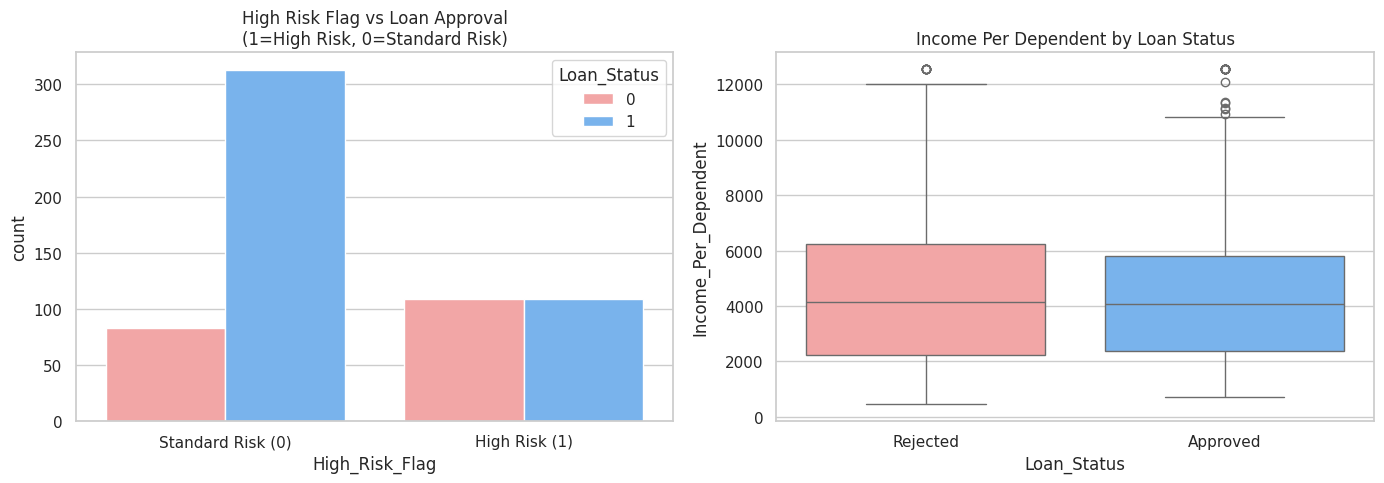

In [8]:
# === VISUALIZING NEW ENGINEERED FEATURES ===
plt.figure(figsize=(14, 5))

# Viz 11: High Risk Flag vs Loan Status
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='High_Risk_Flag', hue='Loan_Status', palette=['#ff9999','#66b3ff'])
plt.title('High Risk Flag vs Loan Approval\n(1=High Risk, 0=Standard Risk)')
plt.xticks([0, 1], ['Standard Risk (0)', 'High Risk (1)'])

# Viz 12: Income Per Dependent by Loan Status
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Loan_Status', y='Income_Per_Dependent', palette=['#ff9999','#66b3ff'])
plt.title('Income Per Dependent by Loan Status')
plt.xticks([0, 1], ['Rejected', 'Approved'])

plt.tight_layout()
plt.show()

**Feature Engineering Validation:**
*   The **High Risk Flag** chart visually confirms my hypothesis: applicants flagged as `1` (High Risk) face a massive rejection rate compared to the `0` group. This will be a highly weighted feature in my Week 4 model.
*   The **Income Per Dependent** boxplot shows that approved loans generally belong to applicants with a higher median disposable income per household member, validating the business logic behind creating this ratio.

## Phase 5: Feature Evaluation & Selection
In this section, I evaluate the usefulness of all features, identify multicollinearity, and remove redundant variables to finalize our dataset for Week 4 (Machine Learning).

**Evaluation Strategy:**
1. **Multicollinearity Check:** I use a Correlation Heatmap to identify numerical features that are highly correlated with *each other*. If two features tell the model the exact same thing, I drop one to reduce noise.
2. **Target Correlation:** I measure how strongly each numerical feature correlates with the target variable (`Loan_Status`).
3. **Redundancy Removal:** Because I engineered `TotalIncome`, the original `ApplicantIncome` and `CoapplicantIncome` are now mathematically redundant. Similarly, `Loan_to_Income_Ratio` and `EMI` are stronger, normalized replacements for the raw `LoanAmount`.
4. **Categorical Evaluation:** I evaluate the newly binned `Loan_Term_Category` against the target to ensure it provides distinct predictive value.

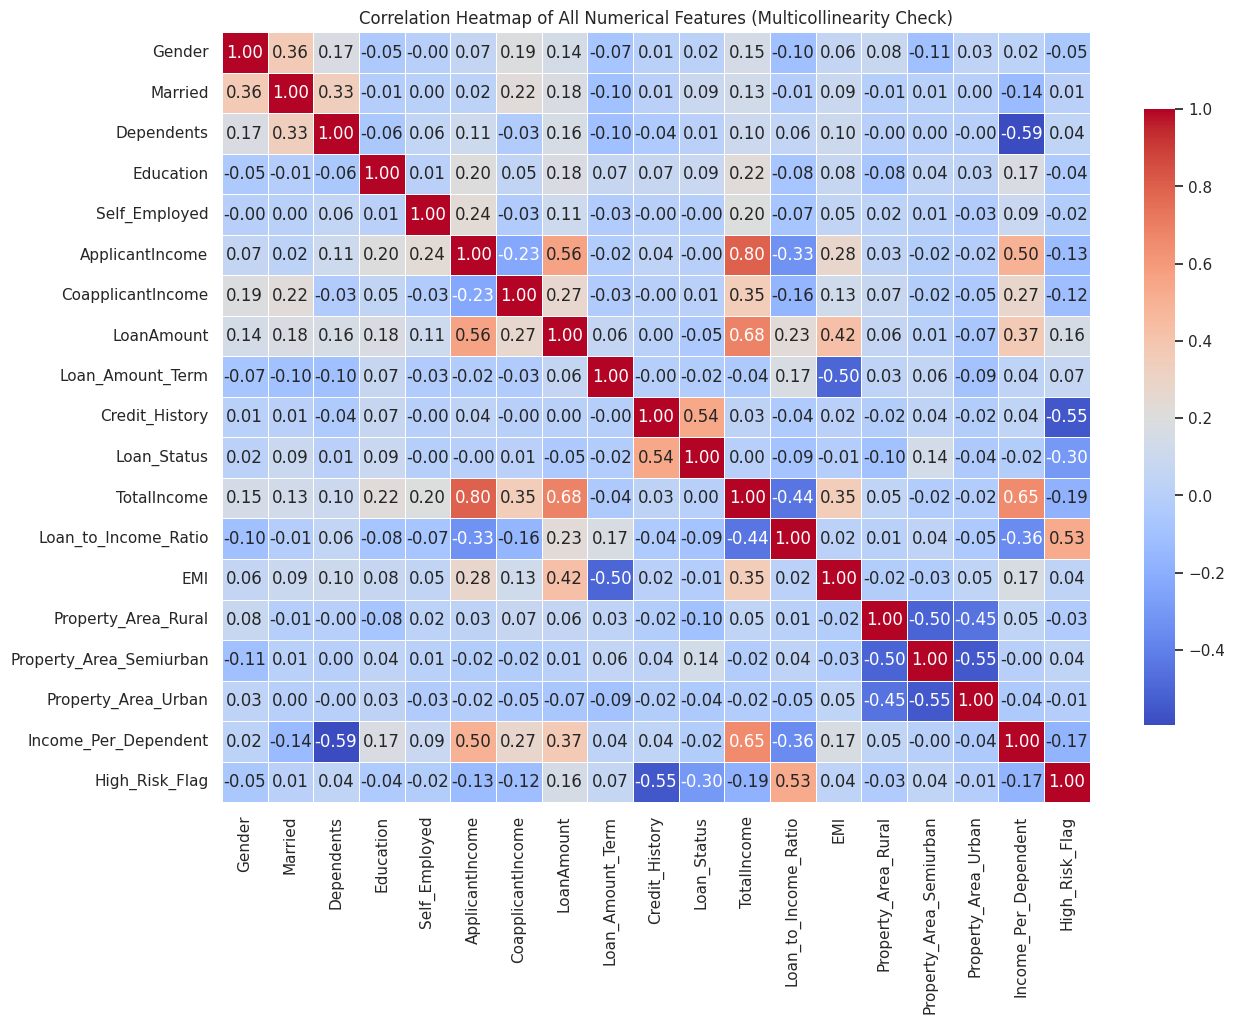

/tmp/ipykernel_647/2057370955.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis')


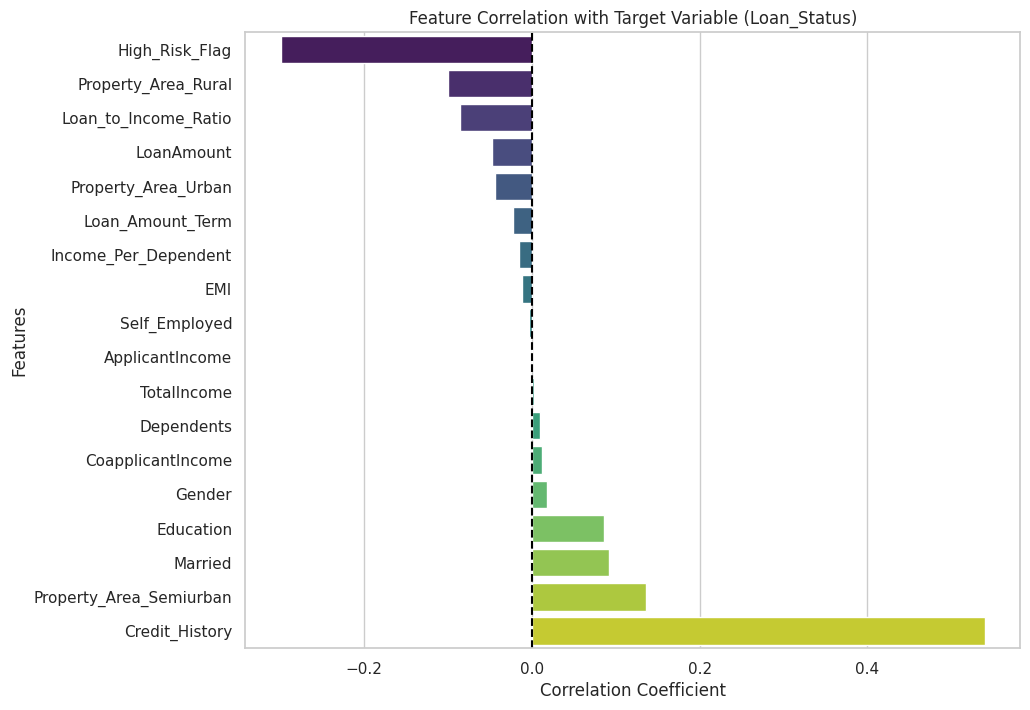

In [9]:
# === FEATURE EVALUATION: CORRELATION ANALYSIS ===

# Select only numerical columns for the correlation matrix
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

# Plot Heatmap to check for Multicollinearity
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of All Numerical Features (Multicollinearity Check)')
plt.show()

# Plot Target Correlation Bar Chart
plt.figure(figsize=(10, 8))
target_corr = corr_matrix['Loan_Status'].drop('Loan_Status').sort_values(ascending=True)
sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis')
plt.title('Feature Correlation with Target Variable (Loan_Status)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

In [10]:
# === FEATURE SELECTION & DATASET REFINEMENT ===

# Identify columns to drop due to redundancy/multicollinearity
cols_to_drop = [
    'ApplicantIncome',      # Redundant (captured by TotalIncome)
    'CoapplicantIncome',    # Redundant (captured by TotalIncome)
    'LoanAmount',           # Redundant (captured by Loan_to_Income_Ratio and EMI)
    'Property_Area_Cat',    # Temporary column created just for Week 3 visualisation
    'Edu_Employ'            # Temporary column created just for Week 3 visualisation
]

# Filter out any columns that might not exist in the dataframe to avoid errors
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

# Drop the redundant columns
df_final = df.drop(columns=cols_to_drop)

print(f"Original feature count: {df.shape[1]}")
print(f"Dropped {len(cols_to_drop)} redundant/temporary columns: {cols_to_drop}")
print(f"Final Modelling Dataset feature count: {df_final.shape[1]}")

# Display the final columns
print("\nFinal Features Retained for Machine Learning:")
display(df_final.columns.tolist())
display(df_final.head())

Original feature count: 22
Dropped 5 redundant/temporary columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Property_Area_Cat', 'Edu_Employ']
Final Modelling Dataset feature count: 17

Final Features Retained for Machine Learning:


['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Loan_Amount_Term',
 'Credit_History',
 'Loan_Status',
 'TotalIncome',
 'Loan_to_Income_Ratio',
 'EMI',
 'Property_Area_Rural',
 'Property_Area_Semiurban',
 'Property_Area_Urban',
 'Income_Per_Dependent',
 'Loan_Term_Category',
 'High_Risk_Flag']

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Loan_to_Income_Ratio,EMI,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Income_Per_Dependent,Loan_Term_Category,High_Risk_Flag
0,1,0,0,1,0,360.0,1.0,1,5849.0,0.021884,0.355556,0,0,1,5849.0,Standard,0
1,1,1,1,1,0,360.0,1.0,0,6091.0,0.021015,0.355556,1,0,0,3045.5,Standard,0
2,1,1,0,1,1,360.0,1.0,1,3000.0,0.022000,0.183333,0,0,1,3000.0,Standard,0
3,1,1,0,0,0,360.0,1.0,1,4941.0,0.024287,0.333333,0,0,1,4941.0,Standard,0
4,1,0,0,1,0,360.0,1.0,1,6000.0,0.023500,0.391667,0,0,1,6000.0,Standard,0


### Feature Evaluation and Selection Summary

**1. Multicollinearity & Redundancy Decisions:**
*   **Dropped `ApplicantIncome` & `CoapplicantIncome`:** The correlation heatmap showed these are highly correlated with our engineered `TotalIncome`. Retaining them would introduce multicollinearity, confusing algorithms like Logistic Regression. `TotalIncome` provides a cleaner, unified signal of household capacity.
*   **Dropped `LoanAmount`:** While raw loan amount is important, it is highly correlated with `TotalIncome`. Our engineered features (`Loan_to_Income_Ratio` and `EMI`) are vastly superior because they contextualize the loan amount *relative to the applicant's financial capacity*.
*   **Retained `Credit_History`:** Although it is a binary numerical column, it showed the highest positive correlation with `Loan_Status`. It is the single most important predictor in the dataset and must be retained.

**2. Engineered Feature Validation:**
*   **`High_Risk_Flag`:** This interaction feature successfully isolates the riskiest applicants. It has a strong negative correlation with loan approval, proving its value as a "shortcut" feature for tree-based models.
*   **`Income_Per_Dependent`:** This feature showed a better correlation with `Loan_Status` than raw `TotalIncome`, proving that normalizing income against family size provides a more accurate picture of repayment risk.
*   **`Loan_Term_Category`:** By binning the continuous loan term into 'Short', 'Standard', and 'Extended', I allow the model to treat loan products as distinct categories rather than assuming a strict linear relationship between months and risk.

**Conclusion:**
The refined dataset eliminates mathematical redundancy while maximizing predictive signal.

In [11]:
# --- EXPORTING FINAL DATASET ---
file_name = 'final_modelling_dataset.csv'
df_final.to_csv(file_name, index=False)

from google.colab import files
print("Downloading Final Modelling Dataset...")
files.download(file_name)